<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week8_NLP_and_ComputerVision/Day%201%20%E2%80%94%20Sprint%203%20Planning%20%26%20NLP%20Preprocessing/Day_1_%E2%80%94_Sprint_3_Planning_%26_NLP_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 3 Planning & NLP Preprocessing



---




# Introduction

In Sprint 2, I developed an initial Transformer-based model using banking dialogue data as the foundation for a customer support chatbot. In this sprint, the focus is on improving the NLP pipeline around that model.

Before text can be processed by a machine learning model, it needs to be converted from raw human language into a consistent numerical representation. This sprint covers the main steps involved in this process, including text cleaning, tokenization, stop-word handling, lemmatization, TF-IDF, embeddings, and evaluation.

The goal is not only to apply these techniques, but also to understand when they are useful and how preprocessing decisions can affect the information available to the model.

---

# Section 1 : Why Does Text Need Preprocessing?

Machine learning models cannot directly understand raw human language. Raw text data is often unstructured, noisy and inconsistent, containing typos, punctuation, stopwords and irrelevant information. Text preprocessing converts this data into a clean, structured and standardized format, enabling effective feature extraction and improving model performance.

Raw text can contain many variations that represent the same idea. For example, the following inputs are slightly different as strings:

```text
"Good"
"good"
"good!"
```

Even though they have essentially the same meaning, a computer may initially treat them as different text patterns.

NLP preprocessing helps reduce these unnecessary differences by cleaning and standardizing text. Common preprocessing operations include lowercasing, removing unnecessary punctuation, tokenizing text, removing selected stop words, and reducing words to their base forms.

However, preprocessing should not remove useful information. This is especially important for a banking chatbot because words such as **"not"**, **"can't"**, or **"never"** can change the meaning of a customer's request.

---

# Section 2 :  Understanding the Banking Dialogue Dataset


The first step is to inspect the text data before applying any preprocessing. This helps identify the available columns, the type of dialogue data, missing values, duplicate entries, and the distribution of intents or categories.

Understanding the dataset before modifying it is important because aggressive preprocessing can remove information that may be useful for classification.

### Implementation

> For this project, I will continue using the **Banking77** dataset that was used for the Transformer model in Sprint 2.

Banking77 contains customer queries related to banking services and assigns them to different intents. Since the project is a banking customer support chatbot, it provides suitable real-world text for experimenting with NLP preprocessing.

### Step 1 : Loading the Banking77 Dataset

In [1]:
!pip install -U transformers datasets==2.18.0 accelerate evaluate scikit-learn

In [3]:
import numpy as np
import pandas as pd

from datasets import load_dataset

# Load the Banking77 dataset
dataset = load_dataset("PolyAI/banking77")

dataset

/usr/local/lib/python3.13/dist-packages/datasets/load.py:1461: FutureWarning: The repository for PolyAI/banking77 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/PolyAI/banking77
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


/root/.cache/huggingface/modules/datasets_modules/datasets/PolyAI--banking77/17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9/banking77.py:25: SyntaxWarning: invalid escape sequence '\~'
  author      = {I{\~{n}}igo Casanueva and Tadas Temcinas and Daniela Gerz and Matthew Henderson and Ivan Vulic},


Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

### Step 2 : Inspect the dataset

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})



We can also inspect individual examples to understand what the raw customer messages look like.

In [5]:
print(dataset["train"][0])
print(dataset["train"][1])
print(dataset["train"][2])

{'text': 'I am still waiting on my card?', 'label': 11}
{'text': "What can I do if my card still hasn't arrived after 2 weeks?", 'label': 11}
{'text': 'I have been waiting over a week. Is the card still coming?', 'label': 11}




### Step 3 : Convert the training data to a DataFrame

In [6]:
train_df = pd.DataFrame(dataset["train"])
display(train_df.head())

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11



### Step 4 : Inspect the available columns

In [7]:
print(train_df.columns)

Index(['text', 'label'], dtype='object')


The main text column contains the customer's query, while the label represents the banking intent associated with that query.



---




# Section 3 : Selecting Raw Text for Preprocessing

Before applying the preprocessing techniques to the complete dataset, it is useful to start with a small number of real examples.

This makes it easier to understand exactly what each preprocessing step changes.

In [8]:
sample_texts = train_df["text"].head(5)

for text in sample_texts:
    print(text)
    print()

I am still waiting on my card?

What can I do if my card still hasn't arrived after 2 weeks?

I have been waiting over a week. Is the card still coming?

Can I track my card while it is in the process of delivery?

How do I know if I will get my card, or if it is lost?




For the first manual experiment, I will also use a sentence containing punctuation, capitalization, and a negation:

In [9]:
sample_text = "I can't make my card payment!"
print(sample_text)

I can't make my card payment!


# Section 4 : Text Processing Techinques

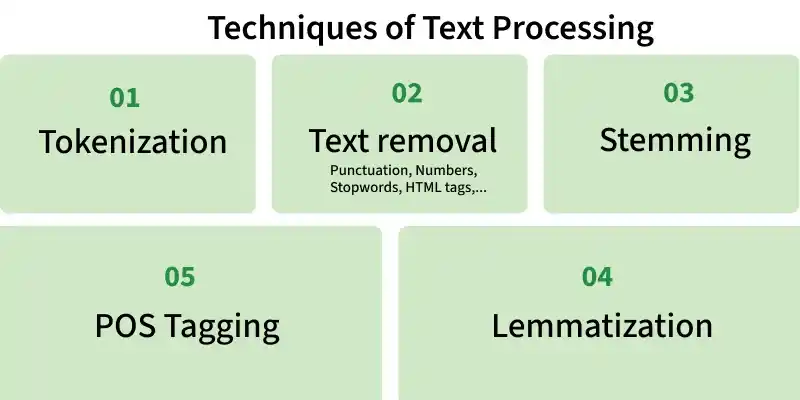

---

## 1. Tokenization




Tokenization is the process of splitting text into smaller units called **tokens**.

For example:

```text
"The movie was great!"
```

can be tokenized into:

```text
["The", "movie", "was", "great", "!"]
```

Tokens are the basic units that NLP systems work with.

There are different types of tokenization. Traditional NLP techniques commonly use word-level tokenization, while modern Transformer models such as the one used in Sprint 2 commonly use **sub-word tokenization**.

Sub-word tokenization is useful because it allows Transformers to handle unfamiliar or rare words by breaking them into smaller pieces instead of treating the entire unknown word as one unit.

### Implementation — Word Tokenization

In [10]:
import nltk

from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

tokens = word_tokenize(sample_text)

print(tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['I', 'ca', "n't", 'make', 'my', 'card', 'payment', '!']


> The nltk.word_tokenize function, by default, tends to split contractions like 'can't' into ['ca', "n't']. This is a common characteristic of its tokenization rules. To achieve 'can not', you would generally need to implement an additional step for expanding contractions in your text preprocessing pipeline.



---



### Tokenizing a Banking77 example

In [11]:
text = train_df["text"].iloc[0]

print("Original text:")
print(text)

print("\nTokens:")
print(word_tokenize(text))

Original text:
I am still waiting on my card?

Tokens:
['I', 'am', 'still', 'waiting', 'on', 'my', 'card', '?']


> This demonstrates how a customer's message is separated into individual tokens before further processing.



##  Cleaning and Normalization

After tokenization, text can be normalized to reduce unnecessary differences between inputs.

The main techniques covered today are:

| Technique           | Purpose                               | Example                |
| ------------------- | ------------------------------------- | ---------------------- |
| Lowercasing         | Removes differences in capitalization | `"Good"` → `"good"`    |
| Punctuation removal | Removes unnecessary symbols           | `"great!"` → `"great"` |
| Stop-word removal   | Removes selected common words         | `"the"` → removed      |
| Lemmatization       | Reduces words to their base form      | `"running"` → `"run"`  |

These techniques are useful for traditional NLP pipelines, but they should always be applied according to the task. Removing or changing text can sometimes remove information that the model needs.

---

## 2.  Lowercasing

Lowercasing converts all characters to lowercase.

For example:

```text
"I NEED HELP WITH MY CARD"
```

becomes:

```text
"i need help with my card"
```

This prevents capitalization from creating unnecessary differences between otherwise identical words.

### Implementation

In [12]:
def lowercase_text(text):
    return text.lower()

lowercase_sample = lowercase_text(sample_text)

print("Original:")
print(sample_text)

print("\nLowercased:")
print(lowercase_sample)

Original:
I can't make my card payment!

Lowercased:
i can't make my card payment!


## 3. Removing Punctuation

Punctuation such as `!`, `?`, `.`, and `,` can sometimes be useful, but they are often removed in traditional text preprocessing when they do not contribute to the classification task.

For example:

```text
"I can't make my payment!"
```

could become:

```text
"I cant make my payment"
```

However, this example also shows an important problem: blindly removing punctuation can change contractions.

Therefore, preprocessing needs to be designed carefully rather than simply removing everything that is not a letter.


### Implementation

In [13]:
import re

def remove_punctuation(text):
    return re.sub(r"[^\w\s]", "", text)

clean_sample = remove_punctuation(lowercase_sample)

print("Before:")
print(lowercase_sample)

print("\nAfter:")
print(clean_sample)

Before:
i can't make my card payment!

After:
i cant make my card payment


> For the banking chatbot, this should be treated as an experiment because contractions and other text patterns may contain useful information.




---




## 4. Stop-Word Removal


Stop words are very common words such as:

```text
the, is, a, an, and, to, of
```

Traditional NLP pipelines sometimes remove these words because they may contribute less information to a classification task.

However, stop-word removal is **task dependent**.

For example:

```text
"I do not recognize this payment."
```

The word `"not"` is extremely important because removing it could change the meaning of the customer's request.

Therefore, for this project, I will inspect the stop-word list and make sure important negation words are preserved.

### Implementation

In [14]:
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("not" in stop_words)
print("no" in stop_words)
print("never" in stop_words)

True
True
False


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.




We can remove selected stop words while preserving important negations.

In [15]:
negation_words = {
    "no",
    "not",
    "nor",
    "never"
}

custom_stop_words = stop_words - negation_words

print("Number of default stop words:", len(stop_words))
print("Number after preserving negations:", len(custom_stop_words))

Number of default stop words: 198
Number after preserving negations: 195




---

## 5. Lemmatization



Lemmatization reduces words to their base or dictionary form.

For example:

```text
cars → car
running → running/run
```

The exact result can depend on the linguistic context and the lemmatization method.

Lemmatization is generally preferred over simple stemming when preserving meaningful words is important because stemming mainly removes parts of words without necessarily producing a valid word.

The purpose is to reduce unnecessary vocabulary variations while keeping the meaning of the original text.

### Implementation

In [16]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

words = ["cars", "running", "payments", "banking"]

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in words
]

for original, lemma in zip(words, lemmatized_words):
    print(f"{original} → {lemma}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


cars → car
running → running
payments → payment
banking → banking



---

# Section 5 : Applying the Full Cleaning Pipeline



The techniques can now be combined into one simple preprocessing function.

The pipeline will:

1. Convert text to lowercase.
2. Remove punctuation.
3. Tokenize the text.
4. Remove selected stop words.
5. Preserve important negation words.
6. Lemmatize the remaining tokens.

### Implementation

In [17]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words while preserving negations
    tokens = [
        word for word in tokens
        if word not in custom_stop_words
    ]

    # Lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens


### Test the complete pipeline

In [18]:
processed = preprocess_text(sample_text)

print("Original:")
print(sample_text)

print("\nProcessed:")
print(processed)

Original:
I can't make my card payment!

Processed:
['cant', 'make', 'card', 'payment']


---

# Section 6: Applying the Pipeline to Banking77

After testing the preprocessing pipeline on individual examples, it can be applied to actual Banking77 queries.

For this first experiment, I will create a new column instead of replacing the original text. This allows the original and processed versions to be compared.


### Implementation

In [19]:
train_df["processed_text"] = train_df["text"].apply(preprocess_text)

display(
    train_df[["text", "processed_text"]].head(10)
)

,text,processed_text
0,I am still waiting on my card?,"[still, waiting, card]"
1,What can I do if my card still hasn't arrived ...,"[card, still, hasnt, arrived, 2, week]"
2,I have been waiting over a week. Is the card s...,"[waiting, week, card, still, coming]"
3,Can I track my card while it is in the process...,"[track, card, process, delivery]"
4,"How do I know if I will get my card, or if it ...","[know, get, card, lost]"
5,When did you send me my new card?,"[send, new, card]"
6,Do you have info about the card on delivery?,"[info, card, delivery]"
7,What do I do if I still have not received my n...,"[still, not, received, new, card]"
8,Does the package with my card have tracking?,"[package, card, tracking]"
9,I ordered my card but it still isn't here,"[ordered, card, still, isnt]"


Keeping the original text is important because preprocessing should be reversible for analysis and comparison.



## Checking Whether Important Information Was Preserved

Preprocessing should simplify text without destroying information that is important for the task.

For a banking chatbot, negations can be particularly important.

For example:

```text
"I do not recognize this payment."
```

and:

```text
"I recognize this payment."
```

have completely different meanings.

Therefore, I will specifically check whether important negation words survive the preprocessing pipeline.

### Implementation

In [20]:
test_sentences = [
    "I do not recognize this payment.",
    "I can't use my card.",
    "I never made this transaction.",
    "I don't want this payment."
]

for sentence in test_sentences:
    print("Original :", sentence)
    print("Processed:", preprocess_text(sentence))
    print()

Original : I do not recognize this payment.
Processed: ['not', 'recognize', 'payment']

Original : I can't use my card.
Processed: ['cant', 'use', 'card']

Original : I never made this transaction.
Processed: ['never', 'made', 'transaction']

Original : I don't want this payment.
Processed: ['dont', 'want', 'payment']



If important words such as `not`, `never`, or similar negations are removed, the preprocessing pipeline should be adjusted rather than assuming that removing all stop words is automatically better.



---



# Section 7 : Day 1 Summary





Today I started Sprint 3 by defining the sprint goal and backlog for improving the banking customer support chatbot.

I then introduced the role of NLP preprocessing and applied the main preprocessing techniques covered in today's material: tokenization, lowercasing, punctuation cleaning, stop-word handling, and lemmatization.

The preprocessing pipeline was tested first on individual examples and then applied to Banking77 customer queries. I also checked that important information, particularly negations, was not unnecessarily removed.

The next steps of Sprint 3 will build on this foundation by exploring additional methods for representing text and improving and evaluating the existing chatbot model.
